# Claims & Utilization Analysis

## Objective
Analyze healthcare claims data to identify cost drivers, utilization patterns, and risk distribution across employees at Company_22.

## Key Questions
- What services drive the most cost?
- Which employees contribute most to claims?
- Are costs concentrated among specific groups?
- Does utilization align with expected risk levels?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
claims = pd.read_csv("https://raw.githubusercontent.com/sadewuya/employee-benefits-analysis/refs/heads/main/data/raw/employer_health_plan_claims_dataset_aligned.csv")
employees = pd.read_csv("https://raw.githubusercontent.com/sadewuya/employee-benefits-analysis/refs/heads/main/data/processed/cleaned_employee_workforce_profile_v2.csv")

In [3]:
company_id = 22

claims_22 = claims[claims["company_id"] == company_id].copy()
employees_22 = employees[employees["company_id"] == company_id].copy()

# validation
assert claims_22.shape[0] > 0, "No claims found for Company_22"
assert employees_22.shape[0] > 0, "No employees found for Company_22"

## Company Scope

This analysis focuses on claims and utilization patterns for Company_22 within the Technology sector to understand cost drivers and healthcare usage behavior.

## Claims Overview

In [4]:
total_claims = claims_22["claim_id"].nunique()
total_claim_cost = claims_22["allowed_amount"].sum()
avg_claim_cost = claims_22["allowed_amount"].mean()

summary = pd.DataFrame({
    "Metric": ["Total Claims", "Total Cost", "Average Claim Cost"],
    "Value": [total_claims, round(total_claim_cost,2), round(avg_claim_cost,2)]
})

summary

,Metric,Value
0,Total Claims,534.00
1,Total Cost,617301.00
2,Average Claim Cost,1155.99


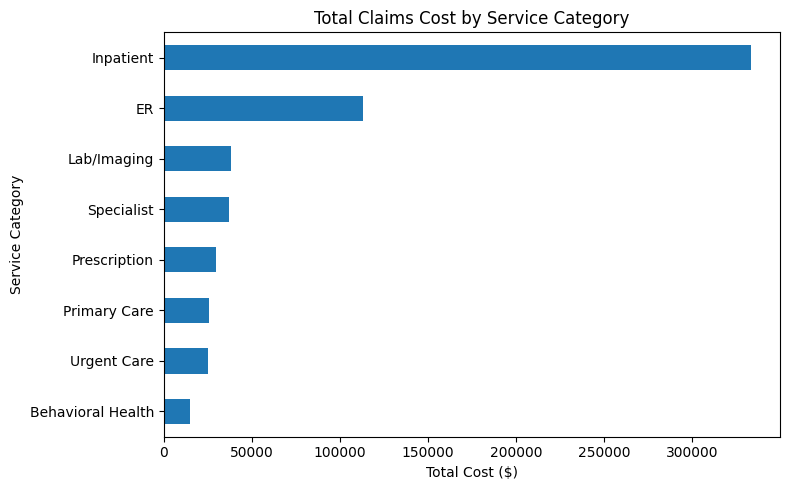

In [5]:
claims_22.groupby("service_category")["allowed_amount"].sum().sort_values().plot(
    kind="barh", figsize=(8,5)
)

plt.title("Total Claims Cost by Service Category")
plt.xlabel("Total Cost ($)")
plt.ylabel("Service Category")
plt.tight_layout()
plt.show()

Interpretation:
Certain service categories account for a disproportionate share of total healthcare costs.

Business Implication:
Identifying these categories helps target cost management strategies such as plan design adjustments or preventative programs. Inpatient claims also imply that the employee is missing significant work time which further increases the cost in multiple areas so its best to spend heavily on preventative programs to mitigate.

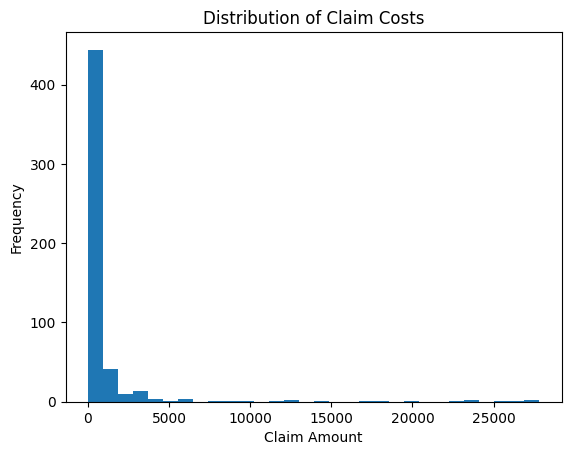

In [6]:
claims_22["allowed_amount"].plot(kind="hist", bins=30)

plt.title("Distribution of Claim Costs")
plt.xlabel("Claim Amount")
plt.ylabel("Frequency")
plt.show()

Interpretation:
Claims are typically right-skewed, with a small number of high-cost claims driving total spend.

Business Implication:
Cost management strategies should focus on high-cost claim events rather than average utilization.

In [7]:
top_costly_employees = claims_22.groupby("employee_id")["allowed_amount"].sum().sort_values(ascending=False).head(10)
top_costly_employees.to_frame(name="Total Claim Cost")

,Total Claim Cost
employee_id,
103038,35690.0
103005,30069.0
103020,29149.0
102945,29020.0
102997,27723.0
103021,27415.0
103003,25114.0
103009,22951.0
102956,21957.0


Interpretation:
A small number of employees contribute disproportionately to total healthcare costs.

Business Implication:
High-cost individuals significantly impact overall spending and should be considered in plan design and risk management strategies. Due to the company's stated values on health consciousness and employee wellness driving those costs down will need to be done creatively.

In [8]:
employee_costs = claims_22.groupby("employee_id")["allowed_amount"].sum().sort_values(ascending=False)

top_10_pct = int(len(employee_costs) * 0.1)

top_cost = employee_costs.head(top_10_pct).sum()
total_cost = employee_costs.sum()

print("Top 10% contribute:", round((top_cost / total_cost) * 100, 2), "% of total cost")

Top 10% contribute: 48.39 % of total cost


Interpretation:
Healthcare costs are highly concentrated among a small subset of employees.

Business Implication:
Broad cost-reduction strategies may be less effective than targeted interventions for high-cost individuals.

In [9]:
merged = claims_22.merge(employees_22, on="employee_id", how="left")

# validation check
assert merged.shape[0] > 0, "Merge failed — no matching employee records"

merged.head()

,claim_id,employee_id,company_id_x,company_name_x,industry_x,plan_type_x,service_category,claim_month,allowed_amount,employee_paid_amount,...,salary,job_level,dependents_count,coverage_tier,chronic_condition_flag,smoker_flag,enrollment_status,utilization_risk_score,risk_category,has_dependents
0,511921,102941,22,Company_22,Technology,HDHP,ER,8,1858.0,614.16,...,Under 50K,Mid,2,Employee + Child(ren),0,0,Enrolled,0.277,Low,Yes
1,511922,102941,22,Company_22,Technology,HDHP,Urgent Care,3,732.0,273.81,...,Under 50K,Mid,2,Employee + Child(ren),0,0,Enrolled,0.277,Low,Yes
2,511923,102941,22,Company_22,Technology,HDHP,Prescription,7,211.0,80.77,...,Under 50K,Mid,2,Employee + Child(ren),0,0,Enrolled,0.277,Low,Yes
3,511924,102942,22,Company_22,Technology,HDHP,Primary Care,5,126.0,40.42,...,75K-100K,Manager,1,Employee + Child(ren),0,0,Enrolled,0.242,Low,Yes
4,511925,102942,22,Company_22,Technology,HDHP,Primary Care,11,266.0,66.35,...,75K-100K,Manager,1,Employee + Child(ren),0,0,Enrolled,0.242,Low,Yes


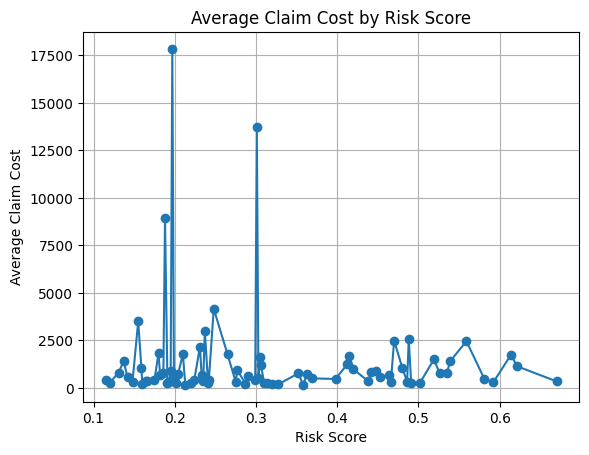

In [10]:
merged.groupby("utilization_risk_score")["allowed_amount"].mean().plot(kind="line", marker="o")

plt.title("Average Claim Cost by Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Average Claim Cost")
plt.grid(True)
plt.show()

Interpretation:
Higher risk scores are associated with increased claim costs.

Business Implication:
This validates the use of risk segmentation in identifying high-cost populations.

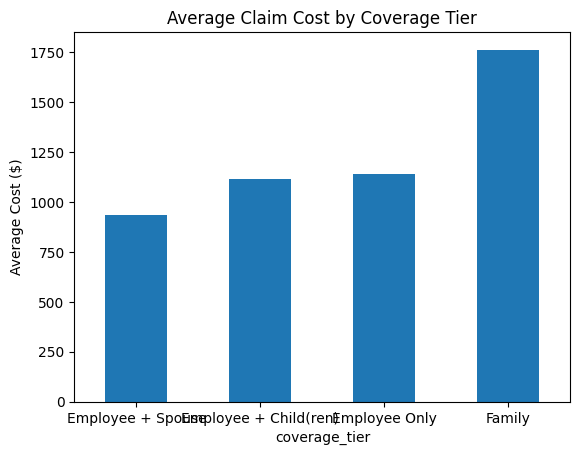

In [11]:
merged.groupby("coverage_tier")["allowed_amount"].mean().sort_values().plot(kind="bar")

plt.title("Average Claim Cost by Coverage Tier")
plt.ylabel("Average Cost ($)")
plt.xticks(rotation=0)
plt.show()

Interpretation:
Employees with family coverage tiers typically incur higher healthcare costs due to dependent utilization.

Business Implication:
Plan design and cost projections should account for increased utilization among employees with dependents.

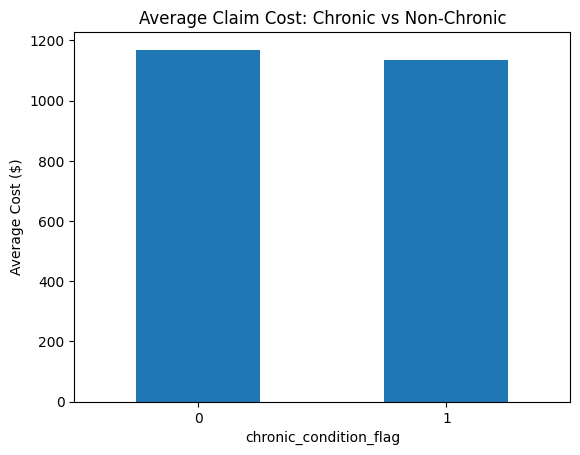

In [12]:
merged.groupby("chronic_condition_flag")["allowed_amount"].mean().plot(kind="bar")

plt.title("Average Claim Cost: Chronic vs Non-Chronic")
plt.ylabel("Average Cost ($)")
plt.xticks(rotation=0)
plt.show()

Insight

From the graph avg claim cost of those who are flagged as having a chronicc condition seem to cost less but the implications suggest that those with chronic conditions will be costly for a longer period of time, also the amount of non-chronic employees who are still actively using their insurance outweighs the chronic so the costs being so close is concerning

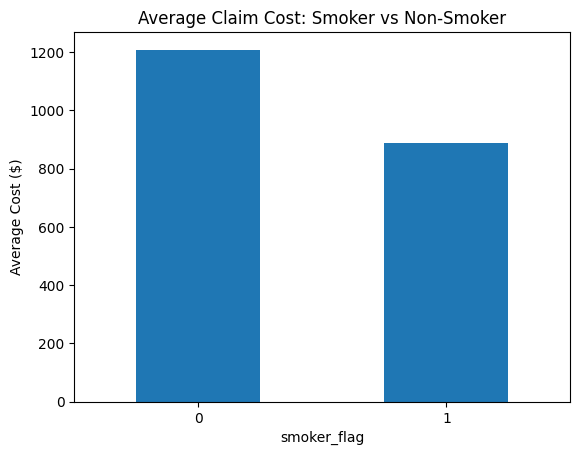

In [13]:
merged.groupby("smoker_flag")["allowed_amount"].mean().plot(kind="bar")

plt.title("Average Claim Cost: Smoker vs Non-Smoker")
plt.ylabel("Average Cost ($)")
plt.xticks(rotation=0)
plt.show()

Lifestyle factors like smoking contribute to elevated healthcare costs and can inform wellness strategies. Since the data suggests that many of the claim costs are driven by families it is safe to assume that smokers in the work force are not driving high costs.

In [14]:
high_cost_claims = claims_22[claims_22["allowed_amount"] > 10000]

high_cost_claims["service_category"].value_counts()

,count
service_category,
Inpatient,14


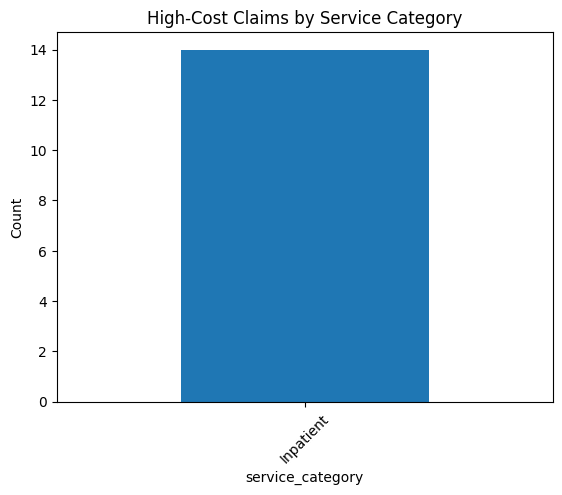

In [15]:
high_cost_claims["service_category"].value_counts().plot(kind="bar")

plt.title("High-Cost Claims by Service Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [16]:
employee_costs = claims_22.groupby("employee_id")["allowed_amount"].sum().sort_values(ascending=False)

top_10_pct = int(len(employee_costs) * 0.1)

top_cost = employee_costs.head(top_10_pct).sum()
total_cost = employee_costs.sum()

print("Top 10% contribute:", round((top_cost / total_cost) * 100, 2), "% of total cost")

Top 10% contribute: 48.39 % of total cost


🧠 Insight

A small percentage of employees typically drive a majority of healthcare costs (Pareto principle).

## Key Claims & Utilization Insights

- Healthcare costs are highly concentrated among a small subset of employees.
- High-cost claims are driven by specific service categories such as inpatient and emergency care.
- Risk score correlates with cost, validating segmentation assumptions.
- Employees with chronic conditions and dependents contribute disproportionately to total spend.
- Overall utilization appears lower than expected relative to employer investment levels.

## Connection to Industry Benchmarking

These findings reinforce Step 3 insights showing that Company_22 has higher employer spending but lower overall claims utilization.

This suggests that current investment levels may exceed actual healthcare demand, particularly among the majority low-risk population.

## Business Implications

- Cost exposure is driven by a small number of high-cost individuals.
- Broad cost optimization strategies may have limited impact.
- Opportunities exist to improve efficiency through targeted interventions and plan design adjustments.